This notebook only serves as a test for fake data

In [1]:
import pandas as pd

fake = pd.read_csv("C:\Master\Masterarbeit\github\master_thesis_SBB\data/fake.csv")

fake.head()

,event_id,train_id,line_id,train_type,station_id,station_lat,station_lon,planned_arrival,actual_arrival,planned_departure,...,hour_of_day,temperature_c,rain_mm,snow_mm,wind_kmh,platform_id,track_id,scheduled_trains_15min,avg_delay_last_3_trains,arrival_delay_next_station_minutes
0,1,101,L1,passenger,STG,47.4239,9.3748,2025-01-15 08:32:00,2025-01-15 08:35:00,2025-01-15 08:34:00,...,8,2.5,0.0,0.0,12,P3,T1,6,1.8,5
1,2,202,L2,passenger,ZRH,47.3782,8.5402,2025-01-15 17:05:00,2025-01-15 17:12:00,2025-01-15 17:07:00,...,17,4.0,1.2,0.0,18,P8,T2,14,4.5,10
2,3,303,L3,suburban,BRN,46.9480,7.4474,2025-02-02 07:14:00,2025-02-02 07:14:00,2025-02-02 07:16:00,...,7,-1.0,0.0,0.0,5,P2,T4,4,0.5,1
3,4,404,L4,freight,OLT,47.3505,7.9032,2025-01-20 02:45:00,2025-01-20 02:52:00,2025-01-20 02:55:00,...,2,1.0,0.0,0.0,9,P1,T6,2,3.2,12
4,5,105,L1,passenger,LUG,46.0037,8.9511,2025-01-18 13:20:00,2025-01-18 13:22:00,2025-01-18 13:22:00,...,13,6.0,3.5,0.0,20,P4,T3,9,2.1,6


In [2]:
# --- Data preparation for XGBoost ---
import pandas as pd

# Drop columns that are not numeric or not useful for prediction
cols_to_drop = [
    'event_id', 'train_id', 'line_id', 'train_type', 'station_id',
    'planned_arrival', 'actual_arrival', 'planned_departure', 'actual_departure',
    'platform_id', 'track_id'
]

# Convert datetime columns to features (hour, minute, weekday)
def add_datetime_features(df, col):
    dt = pd.to_datetime(df[col])
    df[col + '_hour'] = dt.dt.hour
    df[col + '_minute'] = dt.dt.minute
    df[col + '_weekday'] = dt.dt.weekday
    return df

fake_prep = fake.copy()
fake_prep = add_datetime_features(fake_prep, 'planned_arrival')
fake_prep = add_datetime_features(fake_prep, 'planned_departure')

fake_prep = fake_prep.drop(columns=cols_to_drop)

# Select target and features
target_col = 'arrival_delay_minutes'
Y = fake_prep[target_col]
X = fake_prep.drop(columns=[target_col])

# X and Y are now ready for XGBoostBaseline
print(X.head())
print(Y.head())


   station_lat  station_lon  departure_delay_minutes  sequence_in_route  \
0      47.4239       9.3748                        2                  5   
1      47.3782       8.5402                        8                 12   
2      46.9480       7.4474                        0                  3   
3      47.3505       7.9032                       10                  8   
4      46.0037       8.9511                        2                  9   

   is_weekend  is_holiday  hour_of_day  temperature_c  rain_mm  snow_mm  \
0           0           0            8            2.5      0.0      0.0   
1           0           0           17            4.0      1.2      0.0   
2           1           0            7           -1.0      0.0      0.0   
3           0           0            2            1.0      0.0      0.0   
4           0           0           13            6.0      3.5      0.0   

   wind_kmh  scheduled_trains_15min  avg_delay_last_3_trains  \
0        12                       

In [11]:
import xgboost as xgb
import numpy as np
import pandas as pd
import shap

class XGBoostBaseline:
    def __init__(self, params=None):
        self.params = params or {
            "objective": "reg:squarederror",
            "n_estimators": 200,
            "max_depth": 6,
            "learning_rate": 0.05,
            "subsample": 0.8,
            "colsample_bytree": 0.8
        }
        self.models = []

    def fit(self, X, Y):
        # Accept DataFrame or numpy array
        if isinstance(X, pd.DataFrame):
            X_flat = X.values
            n_samples = X.shape[0]
            n_nodes = 1
        else:
            n_samples = X.shape[0]
            n_nodes = X.shape[1] if len(X.shape) > 1 else 1
            X_flat = X.reshape(n_samples * n_nodes, -1) if len(X.shape) > 2 else X

        if isinstance(Y, (pd.Series, pd.DataFrame)):
            Y_flat = Y.values
            if Y_flat.ndim == 1:
                Y_flat = Y_flat[:, None]
        else:
            Y_flat = Y.reshape(Y.shape[0] * Y.shape[1], -1) if len(Y.shape) > 1 else Y[:, None]

        horizon = Y_flat.shape[1]
        self.models = []

        for h in range(horizon):
            model = xgb.XGBRegressor(**self.params)
            model.fit(X_flat, Y_flat[:, h])
            self.models.append(model)

        return self

    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            X_flat = X.values
            n_samples = X.shape[0]
            n_nodes = 1
        else:
            n_samples = X.shape[0]
            n_nodes = X.shape[1] if len(X.shape) > 1 else 1
            X_flat = X.reshape(n_samples * n_nodes, -1) if len(X.shape) > 2 else X

        preds = []
        for model in self.models:
            preds.append(model.predict(X_flat))

        Y_pred = np.stack(preds, axis=1)
        # Reshape to (samples, nodes, horizon) if possible
        if n_nodes > 1:
            return Y_pred.reshape(n_samples, n_nodes, -1)
        else:
            return Y_pred
        

    def feature_importance(self, feature_names=None, importance_type="gain", aggregate="mean"):
        """
        Extract feature importance for each horizon model.

        Parameters:
            feature_names : list of str
            importance_type : 'gain', 'weight', 'cover'
            aggregate : 'mean' or 'sum'

        Returns:
            pd.DataFrame with importance per feature
        """

        all_importances = []

        for model in self.models:
            booster = model.get_booster()
            score = booster.get_score(importance_type=importance_type)

            # Convert to full vector
            if feature_names is None:
                n_features = model.n_features_in_
                feature_names = [f"f{i}" for i in range(n_features)]

            imp = np.zeros(len(feature_names))
            for i, fname in enumerate(feature_names):
                key = f"f{i}"
                imp[i] = score.get(key, 0.0)

            all_importances.append(imp)

        all_importances = np.array(all_importances)

        if aggregate == "mean":
            final_importance = all_importances.mean(axis=0)
        elif aggregate == "sum":
            final_importance = all_importances.sum(axis=0)

        df = pd.DataFrame({
            "feature": feature_names,
            "importance": final_importance
        }).sort_values("importance", ascending=False)

        return df
    
    def shap_importance(self, X_sample):
        shap_values_all = []

        for model in self.models:
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_sample)
            shap_values_all.append(np.abs(shap_values))

        shap_values_all = np.array(shap_values_all)

        # Mean across horizons and samples
        mean_shap = shap_values_all.mean(axis=(0,1))

        return mean_shap


In [12]:
my_xgboost = XGBoostBaseline()



my_xgboost.fit(X, Y)

prediction = my_xgboost.predict(X)

print(prediction)

importance_df = my_xgboost.feature_importance(
    feature_names=X.columns.tolist(),
    importance_type="gain"
)

print(importance_df.head(10))


[[3.0005286 ]
 [6.996904  ]
 [0.06724259]
 [6.9740047 ]
 [1.9916948 ]]
                               feature  importance
2              departure_delay_minutes    3.925707
12             avg_delay_last_3_trains    3.565184
13  arrival_delay_next_station_minutes    1.207140
3                    sequence_in_route    1.145572
15              planned_arrival_minute    0.320216
1                          station_lon    0.115506
0                          station_lat    0.065206
6                          hour_of_day    0.001390
18            planned_departure_minute    0.000000
17              planned_departure_hour    0.000000


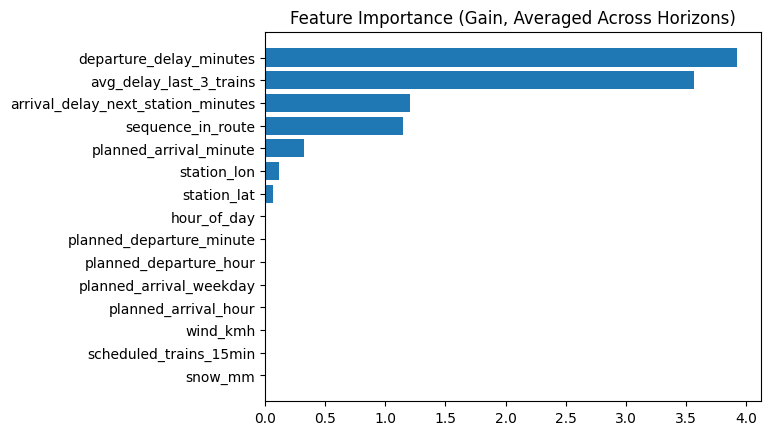

In [13]:
import matplotlib.pyplot as plt

top_k = 15
plt.barh(
    importance_df["feature"][:top_k],
    importance_df["importance"][:top_k]
)
plt.gca().invert_yaxis()
plt.title("Feature Importance (Gain, Averaged Across Horizons)")
plt.show()


# SHAP analysis

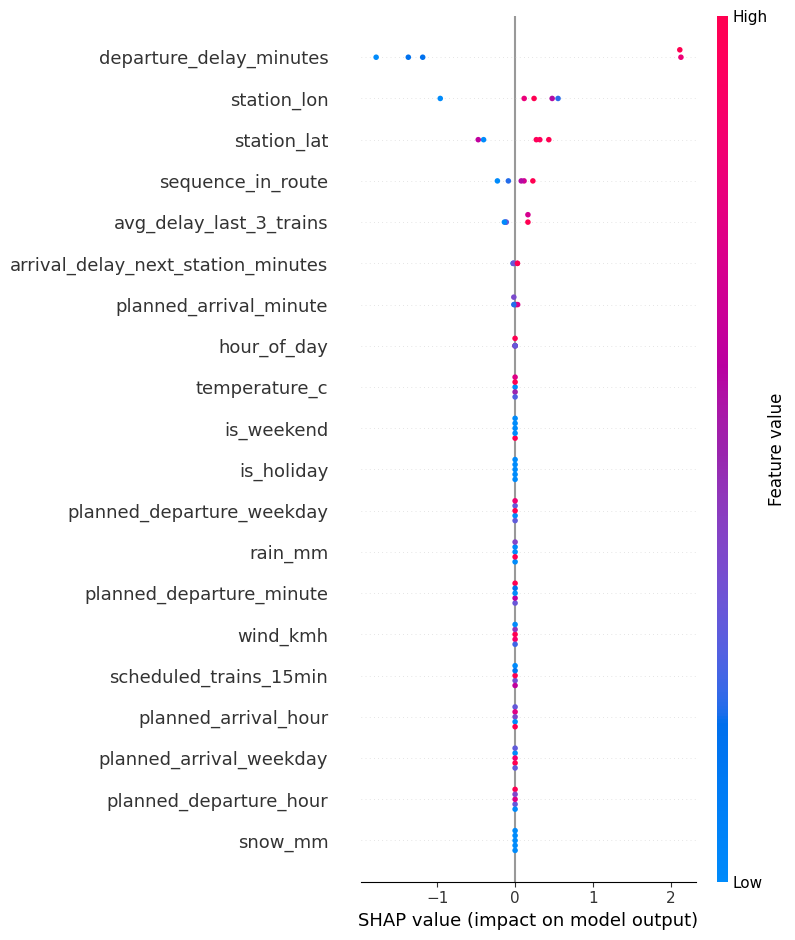

In [14]:
import shap

mean_shap = my_xgboost.shap_importance(X)

shap.summary_plot(
    shap.TreeExplainer(my_xgboost.models[0]).shap_values(X),
    X
)

# Advanced: Horizon-Specific Importance Heatmap

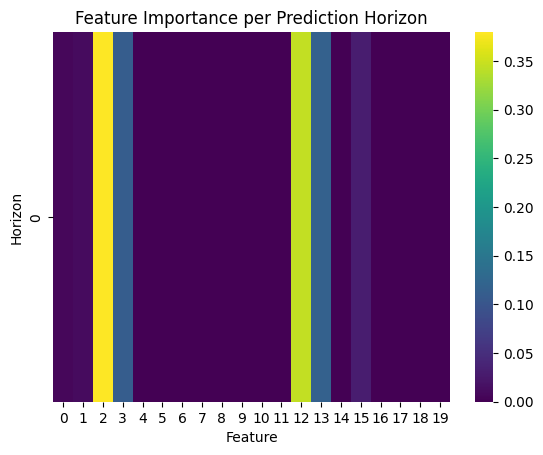

In [15]:
import seaborn as sns

all_imp = []
for model_h in my_xgboost.models:
    all_imp.append(model_h.feature_importances_)

all_imp = np.array(all_imp)

sns.heatmap(all_imp, cmap="viridis")
plt.xlabel("Feature")
plt.ylabel("Horizon")
plt.title("Feature Importance per Prediction Horizon")
plt.show()